In [37]:
# imports 

# model, training, and metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# for graphing the mae
import matplotlib.pyplot as mlt
from matplotlib.widgets import Slider, Button

# for managing the csv datasets
import pandas as pd

In [38]:
# load in the csv file
data = pd.read_csv("Datasets/AmesHousing/AmesHousing.csv")
data.describe()
print(data.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [39]:
# set prediction variable and features
y = data.SalePrice

features = ['Lot Frontage', 'Lot Area',  
            'House Style', 'Overall Cond', 'Year Built', 
            '1st Flr SF', '2nd Flr SF', 'Full Bath', 'TotRms AbvGrd', 'Half Bath']
x = data[features]

In [40]:
# split training and validation data, encode
train_X, val_X, train_y, val_y = train_test_split(x,y, random_state=0)

ordEncoder = OrdinalEncoder()
object_columns = [col for col in train_X.columns if train_X[col].dtype == "str"]

train_X[object_columns] = ordEncoder.fit_transform(train_X[object_columns])
val_X[object_columns] = ordEncoder.fit_transform(val_X[object_columns])

In [83]:
# start collecting points for plot
MAEcurve = list()
for i in range(1,100):
    # train and fit model, get mean absoluteion error/loss
    model = DecisionTreeRegressor(
        max_leaf_nodes=(2+(10*i)),
        random_state=1
    )

    model.fit(train_X,train_y)

    train_predictions = model.predict(train_X)
    train_mae = mean_absolute_error(train_y,train_predictions)

    val_predictions = model.predict(val_X)
    val_mae = mean_absolute_error(val_y,val_predictions)
    MAEcurve.append((train_mae,val_mae))

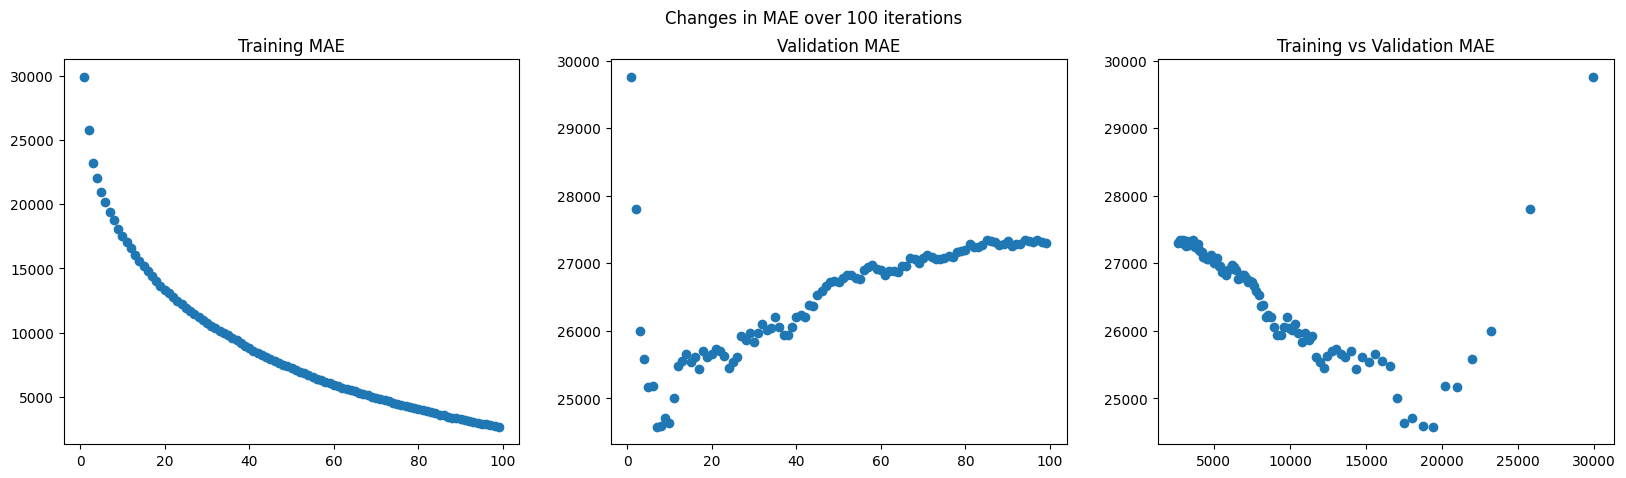

6


In [ ]:
fig, ax = mlt.subplots(1,3)
fig.set_size_inches(20,5)
x, y =  zip(*MAEcurve)
# x --> training mae
# y --> validation mae
ax[0].scatter(range(1,100),x)
ax[1].scatter(range(1,100),y)
ax[2].scatter(x,y)

fig.suptitle("Changes in MAE over 100 iterations")
ax[0].set_title('Training MAE')
ax[1].set_title('Validation MAE')
ax[2].set_title('Training vs Validation MAE')

print(y.index(min(y)))

mlt.show()

**Interpretation:**
As the model grows too complex (higher iterations), the training MAE will shrink, as the model fits to the training data more, and the validation MAE will grow, because the model will be overfit and perform worse on new data. We are looking for the point where the validation MAE is minimized. 

Using ``` y.index(min(y)) ``` we find the iteration where the validation MAE is minimized to be 6. This has a max tree node size of 62.